## Q1

In [1]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

In [2]:
def myloess(dat, lamda, numpts):
    
    '''
    The function takes data, a bandwidth parameter, and the number of x-points as input,
    and returns a matrix containing the numpts x-values and the corresponding evaluated y-values at each point.
    
    dat    : x and y values  
    lamda  : bandwidth parameter
    numpts : number of x-points
    '''
    
    x = dat[:, 0] 
    y = dat[:, 1]
    
    points = np.linspace(min(x), max(x), numpts) # generate equally spaced points over the range of the x-values
    s = 2 * (lamda * np.std(x))**2 # calculate the exponential (numerator) part of the normal distribution.
    y_loess = [] # array to store evaluated y-values at each point.
    
    for x0 in points:
        # calculate distance
        dist = (x - x0)**2
        # convert to weight
        w = np.exp(-(dist/s))
        # add intercept
        X = sm.add_constant(x)
        # fit weighted least square
        model = sm.WLS(y, X, weights=w).fit()
        # evaluate at x0
        y0 = model.predict([1, x0])[0]
        y_loess.append([x0, y0])
    
    y_loess = np.array(y_loess)
    
    plt.figure(figsize=(8,5))
    # plot the original data points
    plt.scatter(x, y, facecolor='none', edgecolors='black')
    # plot fitted model
    plt.plot(y_loess[:,0], y_loess[:,1], color="red", linestyle="--", label="loess fit")

    plt.legend()
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("fit with loess function")
    plt.tight_layout()
    plt.show()
        
    return y_loess

#### Case 1

Here, I simulate sin(x) as the true function and add Gaussian noise N(mu=0, sd=0.3) to generate the response y. The myloess function is then applied, using 10 evaluation points and lamda = 0.2, to fit the data via weighted least squares.

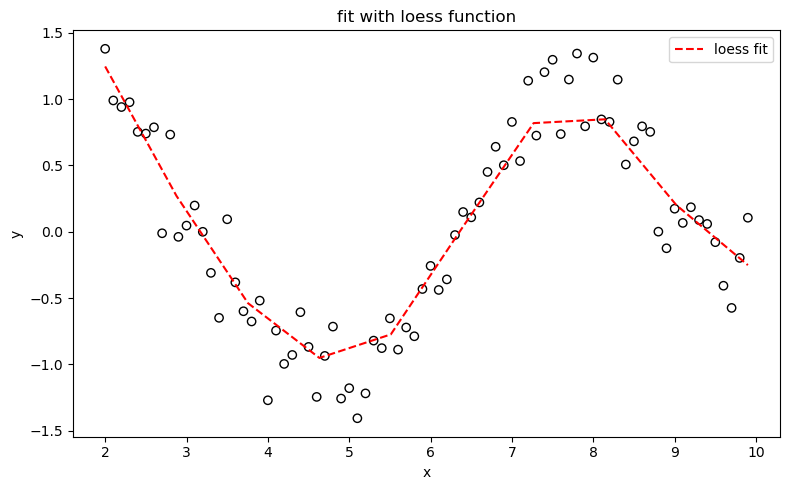

[[ 2.      1.2468]
 [ 2.8778  0.2695]
 [ 3.7556 -0.5382]
 [ 4.6333 -0.9513]
 [ 5.5111 -0.7738]
 [ 6.3889  0.0298]
 [ 7.2667  0.8194]
 [ 8.1444  0.8481]
 [ 9.0222  0.2005]
 [ 9.9    -0.2512]]


In [3]:
xpts = np.arange(2, 10, 0.1)
f = np.sin(xpts)
ypts = f + np.random.normal(0, 0.3, len(xpts))

data = np.zeros((len(xpts), 2))
data[:, 0] = xpts
data[:, 1] = ypts

y_loess = myloess(data, 0.2, 10)
print(y_loess)

The above figure shows the original data points and the fitted LOESS curve. Here, we can see that, the LOESS curve closely follows the data pattern.

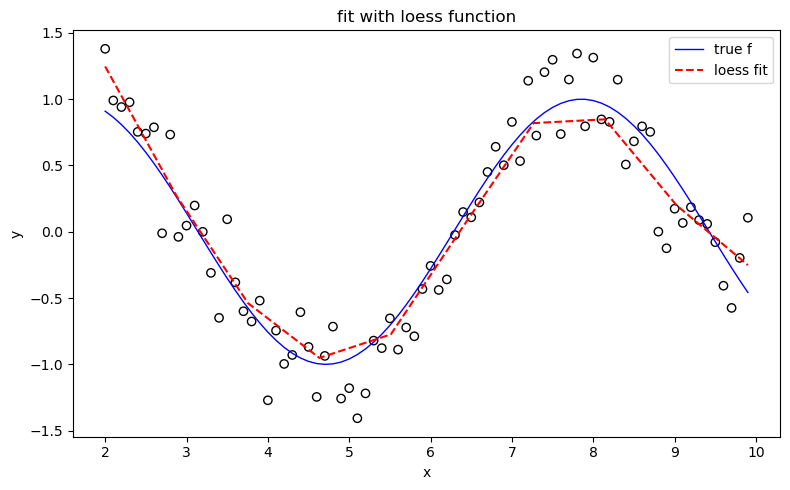

In [4]:
plt.figure(figsize=(8,5))
# plot the original data points
plt.scatter(xpts, ypts, facecolor='none', edgecolors='black')
# plot the true function
idx = np.argsort(xpts)
plt.plot(xpts[idx], f[idx], color= "blue", linewidth=1.0, label="true f")
# plot fitted model
plt.plot(y_loess[:,0], y_loess[:,1], color="red", linestyle="--", label="loess fit")
    
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("fit with loess function")
plt.tight_layout()
plt.show()

The above figure shows the original data points along with the fitted LOESS curve. The LOESS curve closely follows the data pattern, effectively capturing the overall structure of the data.

#### Case 2

For case 2, I simulate $$10*sin(x) + 0.5*x^2$$ as the true function and add Gaussian noise N(mu=0, sd=3) to generate the response y. The myloess function is then applied, using 10 evaluation points with lamda = 0.2, to fit the data via weighted least squares.

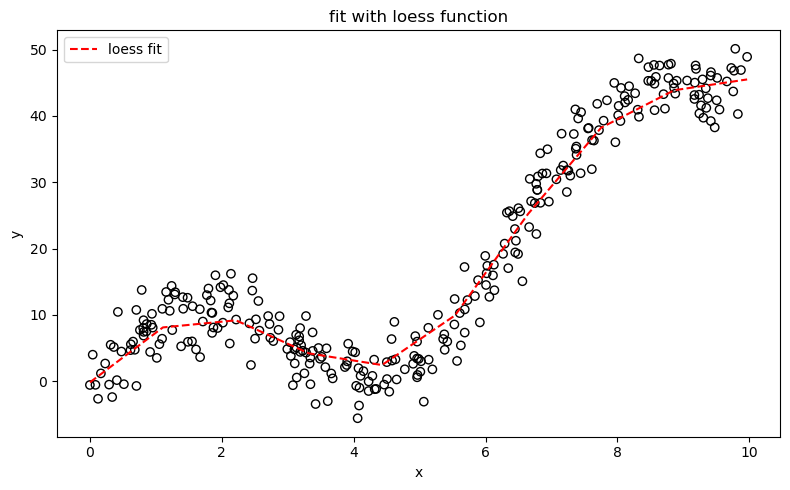

In [5]:
xpts = np.random.uniform(0, 10, 300)
xpts = np.sort(xpts)

f = 10*np.sin(xpts) + 0.5*xpts**2
ypts = f + np.random.normal(0, 3, len(xpts))

data = np.zeros((len(xpts), 2))
data[:, 0] = xpts
data[:, 1] = ypts

y_loess = myloess(data, 0.2, 10)

The figure above shows the original data points and the fitted LOESS curve. Using 10 evaluation points with lamda = 0.2, the LOESS curve still closely follows the data pattern.

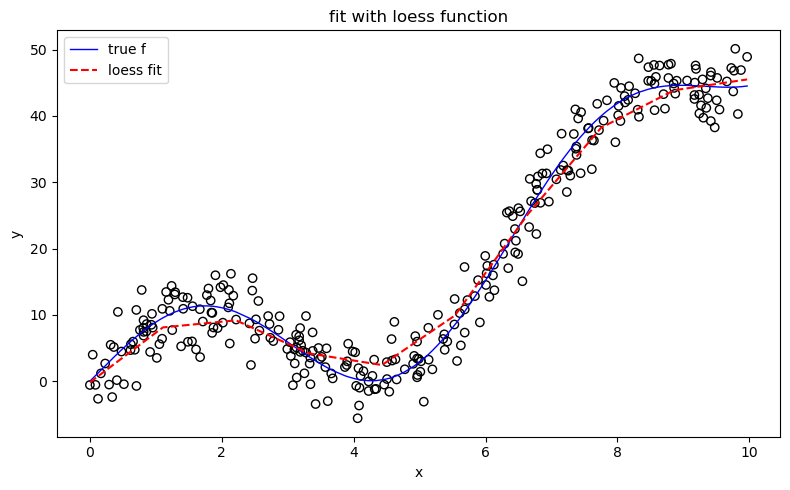

In [6]:
plt.figure(figsize=(8,5))
# Plot the original data points
plt.scatter(xpts, ypts, facecolor='none', edgecolors='black')
# Plot the true function
idx = np.argsort(xpts)
plt.plot(xpts[idx], f[idx], color= "blue", linewidth=1.0, label="true f")
# plot fitted model
plt.plot(y_loess[:,0], y_loess[:,1], color="red", linestyle="--", label="loess fit")

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("fit with loess function")
plt.tight_layout()
plt.show()

The above figure shows the original data points, the true regression function, and the fitted LOESS curve. The fitted curve achieves a good balance between bias and variance, effectively capturing the underlying pattern of the data.

#### Case 3

In Case 3, I increase the variance to examine high-variance noise.

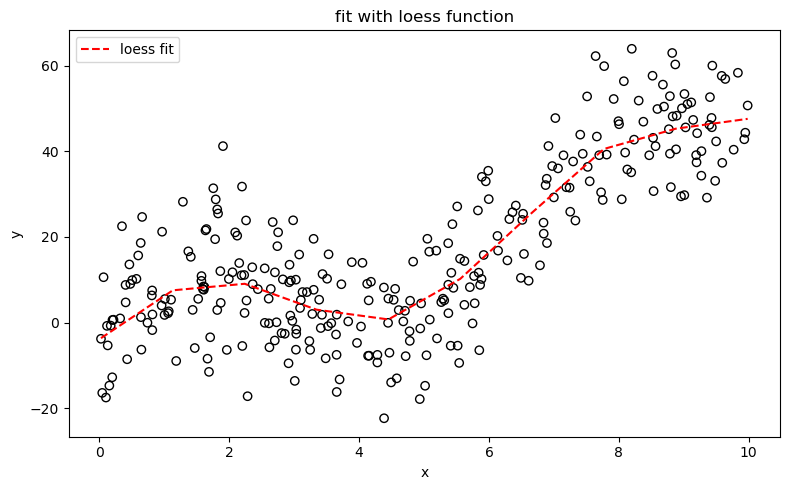

In [7]:
xpts = np.random.uniform(0, 10, 300)
xpts = np.sort(xpts)

f = 10*np.sin(xpts) + 0.5*xpts**2
ypts = f + np.random.normal(0, 10, len(xpts))

data = np.zeros((len(xpts), 2))
data[:, 0] = xpts
data[:, 1] = ypts

y_loess = myloess(data, 0.2, 10)

The figure presents the observed data points and the fitted LOESS curve under homogeneous high-variance noise.

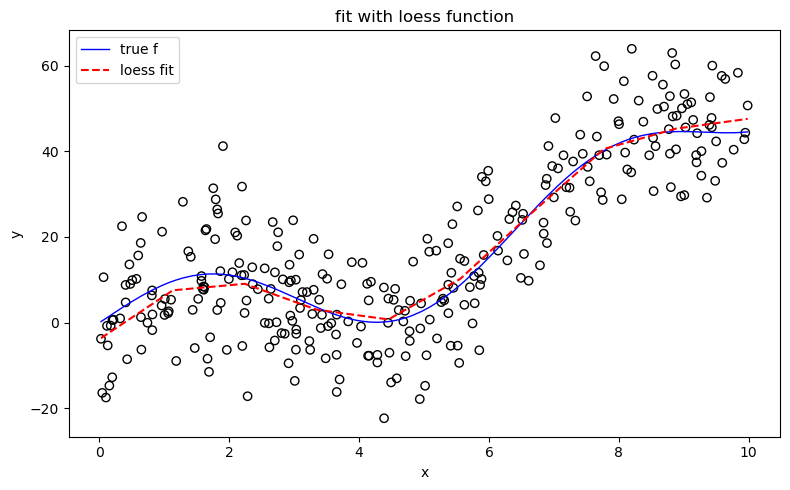

In [8]:
plt.figure(figsize=(8,5))
# Plot the original data points
plt.scatter(xpts, ypts, facecolor='none', edgecolors='black')
# Plot the true function
idx = np.argsort(xpts)
plt.plot(xpts[idx], f[idx], color= "blue", linewidth=1.0, label="true f")
# plot fitted model
plt.plot(y_loess[:,0], y_loess[:,1], color="red", linestyle="--", label="loess fit")

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("fit with loess function")
plt.tight_layout()
plt.show()

The figure shows the original data points, the true regression function, and the fitted LOESS curve. Under high constant variance, the LOESS curve produces a smooth fit that captures the overall trend of the data. However, the fitted curve is still slightly biased.

#### Case 4

Finally, in Case 4, I increase both the model complexity and the noise variance. In this case, I set heterogeneous variance and use sin(2x) as the true regression function.

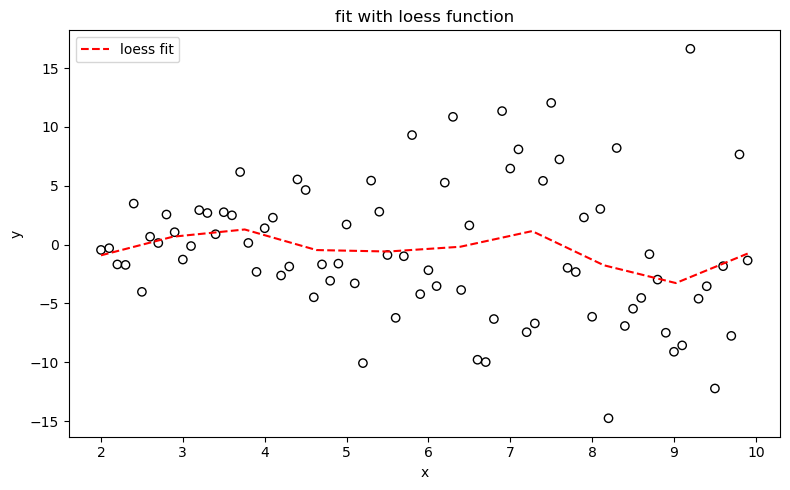

In [9]:
xpts = np.arange(2, 10, 0.1)
f = np.sin(2*xpts)
ypts = f + np.random.normal(0, xpts, size=len(xpts))

data = np.zeros((len(xpts), 2))
data[:, 0] = xpts
data[:, 1] = ypts

y_loess = myloess(data, 0.2, 10)

The figure shows the original data points and the fitted LOESS curve for heterogeneous variance.

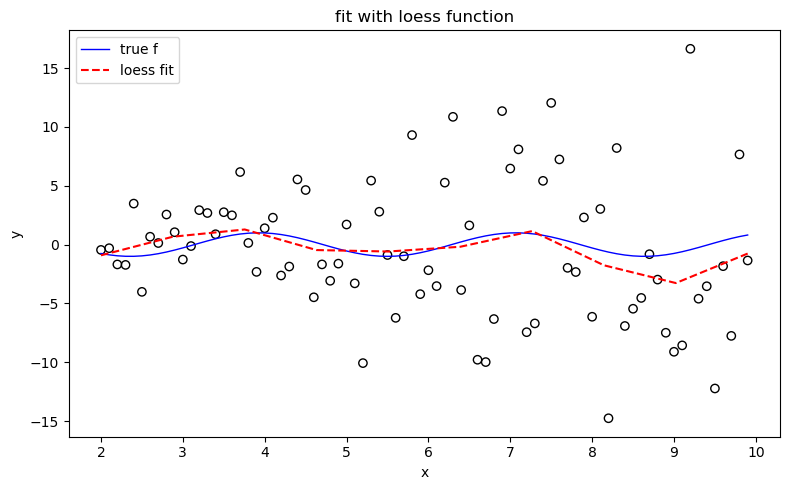

In [10]:
plt.figure(figsize=(8,5))
# Plot the original data points
plt.scatter(xpts, ypts, facecolor='none', edgecolors='black')
# Plot the true function
idx = np.argsort(xpts)
plt.plot(xpts[idx], f[idx], color= "blue", linewidth=1.0, label="true f")
# plot fitted model
plt.plot(y_loess[:,0], y_loess[:,1], color="red", linestyle="--", label="loess fit")

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("fit with loess function")
plt.tight_layout()
plt.show()

The figure shows the original data points, the true regression function, and the fitted LOESS curve for data with heterogeneous variance. In the presence of heteroscedasticity, the LOESS curve captures the overall trend but becomes less reliable in regions with higher variability, where the fit is more influenced by noisy observations.

## Q2

In [11]:
from statsmodels.nonparametric.smoothers_lowess import lowess
    
def findspan(dat, smoothvec, k, plotY):
    '''
    The function takes the data, a vector of span values, and k as input, 
    and returns the optimal span value based on k-fold cross-validation.
    
    data      : x and y values 
    smoothvec : vector of span values 
    k         : number of folds for k-fold cross-validation 
    ploty     : binary indicator of whether to plot or not
    '''
    dat = dat[dat[:, 0].argsort()] # sort data based on x-values
    x = dat[:, 0]
    y = dat[:, 1]
    
    # assign folds to data points
    N = len(x)
    r = int(np.floor(N/k) + 1)
    folds = np.repeat(np.arange(1, k+1), r) 
    np.random.shuffle(folds)
    folds = folds[:N]
    
    MSEvec = np.zeros(len(smoothvec))
    
    # loop over span values
    for s in range(len(smoothvec)):
        MSE = 0
        # perform k-fold cross-validation
        for f in range(1, k+1):
            X_train, y_train = x[folds!=f], y[folds!=f]
            X_test, y_test = x[folds==f], y[folds==f]
            y_pred = lowess(y_train, X_train, frac=smoothvec[s], xvals=X_test)
            MSE += np.mean((y_test - y_pred)**2)

        MSEvec[s] = MSE/k

    # get the optimal span based on the minimum cross-validation MSE
    best_span = smoothvec[np.argmin(MSEvec)]
    
    # plot the data with the optimal span
    if plotY == True:
        y_loess = lowess(y, x, frac=best_span, return_sorted=True)
        
        plt.figure(figsize=(8,5))
        # plot the original data points
        plt.scatter(x, y, facecolor='none', edgecolors='black')
        # plot fitted model
        plt.plot(y_loess[:,0], y_loess[:,1], color="red", linestyle="--", label=f"optimal span: {best_span:.2f}")

        plt.legend()
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title("fit with loess function")
        plt.tight_layout()
        plt.show()
        
    return best_span


#### Case 1 

Here, I simulate sin(x) as the true function and add Gaussian noise N(mu=0, sd=3) to generate the response y. The findspan function is then applied, using smoothvec from 0.1 to 1 increase by 0.1, to fit the data via weighted least squares using k-fold cross validation.

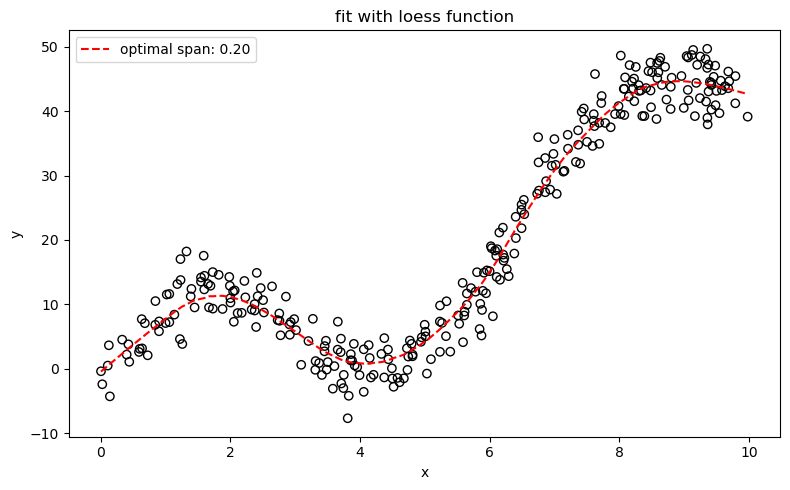

Optimal span value: 0.20


In [12]:
xpts = np.random.uniform(0, 10, 300)
xpts = np.sort(xpts)

f = 10*np.sin(xpts) + 0.5*xpts**2
ypts = f + np.random.normal(0, 3, len(xpts))


data = np.zeros((len(xpts), 2))
data[:, 0] = xpts
data[:, 1] = ypts

smoothvec = np.arange(0.1, 1, 0.1)
k = 5
plotY = True
best_span = findspan(data, smoothvec, k, plotY)  

print(f"Optimal span value: {best_span:.2f}")

With the optimal span value, which provides the lowest MSE in k-fold cross-validation, the LOESS method achieves a good balance between bias and variance, producing a smooth curve that closely follows the underlying trend of the data.

#### Case 2 

In Case 2, the true function was sin(2x), introducing higher-frequency oscillations.

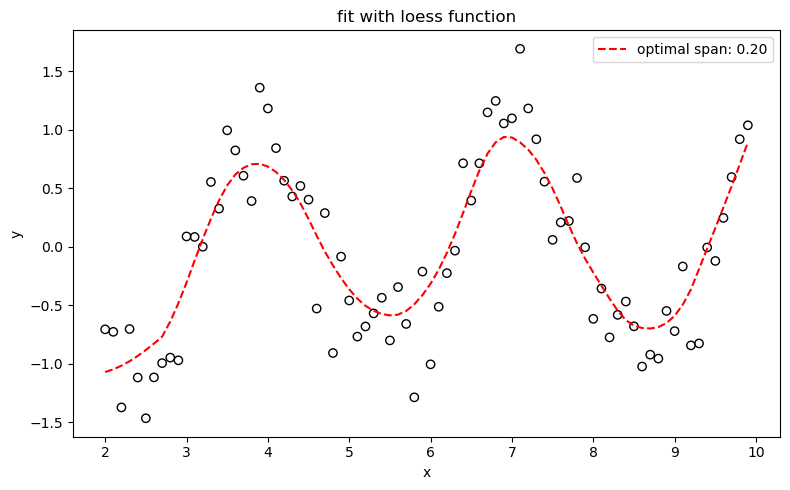

Optimal span value: 0.20


In [13]:
xpts = np.arange(2, 10, 0.1)
#xpts = np.random.uniform(0,10, 1000)
#xpts = np.sort(xpts)
f = np.sin(2*xpts)
ypts = f + np.random.normal(0, 0.3, len(xpts))

data = np.zeros((len(xpts), 2))
data[:, 0] = xpts
data[:, 1] = ypts

smoothvec = np.arange(0.1, 1, 0.1)
k = 5
plotY = True
best_span = findspan(data, smoothvec, k, plotY)  
print(f"Optimal span value: {best_span:.2f}")

Here, we can see that the findspan function returns an optimal span value, which effectively captures the underlying trend of the data.


#### Case 3 

In Case 3, the true function was made by using sin(5x), introducing higher-frequency oscillations.

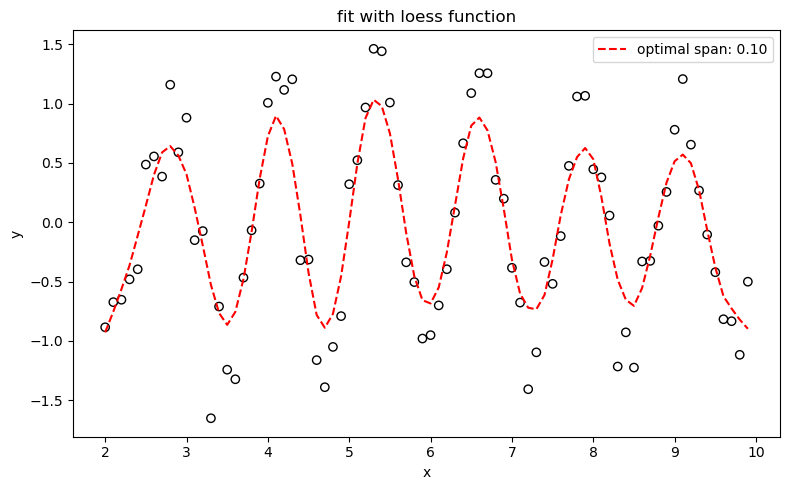

Optimal span value: 0.10


In [14]:
xpts = np.arange(2, 10, 0.1)
f = np.sin(5*xpts)
ypts = f + np.random.normal(0, 0.3, len(xpts))

data = np.zeros((len(xpts), 2))
data[:, 0] = xpts
data[:, 1] = ypts

smoothvec = np.arange(0.1, 1, 0.1)
k = 5
plotY = True
best_span = findspan(data, smoothvec, k, plotY)  
print(f"Optimal span value: {best_span:.2f}")

Here, we can see that the findspan function returns an optimal span value, which effectively captures the underlying trend of the data.

# Q3

In [15]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

def getdk(X, knots, idx):
    ''''    
    This is a helper function for bmat. 
    It computes dk(X) for the basis matrix.    
    '''
    e1 = np.maximum(0, X - knots[idx])**3  # first part of the equation
    e2 = np.maximum(0, X - knots[-1])**3 # second part of the equation
    return (e1 - e2) / (knots[-1] - knots[idx])

def bmat(dat, k):
    '''
    The function takes the dat and k as inputs, 
    generates the basis matrix, fits a linear model on the basis matrix, 
    and returns the basis matrix and the fitted model object.
    
    dat  : x and y values
    k    : number of knots
    '''
    
    dat = dat[dat[:, 0].argsort()] # sort data based on x-values
    x = dat[:, 0]
    y = dat[:, 1]
    
    # evenly spaced knots
    knots = np.linspace(np.min(x), np.max(x), k + 2)[1:-1]    
    basis = np.zeros((len(x), k))
    
    # N1 = Intercept
    if k >= 1:
        basis[:, 0] = np.ones(len(x))
        
    # N2 = x
    if k >= 2:
        basis[:, 1] = x
        
    
    if k > 2:
        Nm1 = getdk(x, knots, k - 2)
        for i in range(k - 2):
            Ni = getdk(x, knots, i)    
            basis[:, i + 2] = Ni - Nm1
            
    # fit model
    model = sm.OLS(y, basis).fit() 
    

    plt.figure(figsize=(8, 5))
    # plot the original data points
    plt.scatter(x, y, facecolor='none', edgecolors='black')
    # plot the fitted model
    plt.plot(x, model.fittedvalues, color="red", linestyle="--", label='fitted spline')
    plt.title(f"Natural Cubic Spline (k={k})")
    plt.legend()
    plt.show()
    
    out = {"basis": basis, "model": model}
    
    return out

#### Case 1 

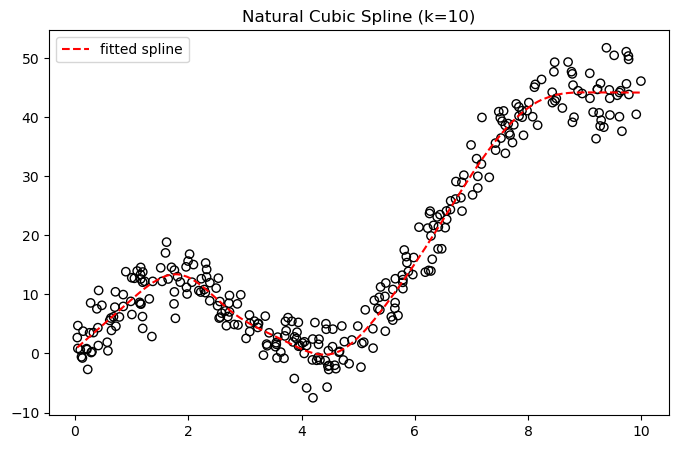

In [16]:
xpts = np.random.uniform(0, 10, 300)
xpts = np.sort(xpts)

f = 10*np.sin(xpts) + 0.5*xpts**2
ypts = f + np.random.normal(0, 3, len(xpts))

data = np.zeros((len(xpts), 2))
data[:, 0] = xpts
data[:, 1] = ypts

results = bmat(data, 10)

In [17]:
results['basis']

array([[ 1.    ,  0.0402,  0.    , ...,  0.    ,  0.    ,  0.    ],
       [ 1.    ,  0.0502,  0.    , ...,  0.    ,  0.    ,  0.    ],
       [ 1.    ,  0.0505,  0.    , ...,  0.    ,  0.    ,  0.    ],
       ...,
       [ 1.    ,  9.781 , 80.5333, ..., 17.9179, 10.3076,  4.335 ],
       [ 1.    ,  9.9116, 83.3687, ..., 18.9811, 11.0165,  4.6894],
       [ 1.    ,  9.9939, 85.156 , ..., 19.6514, 11.4633,  4.9128]])

In [18]:
results['model'].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.964
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                     870.3
Date:                Fri, 03 Apr 2026   Prob (F-statistic):          4.05e-204
Time:                        22:49:43   Log-Likelihood:                -759.85
No. Observations:                 300   AIC:                             1540.
Df Residuals:                     290   BIC:                             1577.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6681      0.753      0.887      0.376      -0.815       2.151
x1             8.4907      0.748     11.348      0.000       7.018       9.963
x2           -33.1224      4.132     -8.016      0.000     -41.255     -24.990
x3            70.3776     12.768      5.512      0.000      45.248      95.508
x4           -48.4864     18.029     -2.689      0.008     -83.970     -13.003
x5            31.7001     17.991      1.762      0.079      -3.710      67.110
x6           -29.9530     15.569     -1.924      0.055     -60.596       0.690
x7             9.0694     12.689      0.715      0.475     -15.904      34.043
x8            -3.5137      9.616     -0.365      0.715     -22.440      15.412
x9             1.2452      5.862      0.212      0.832     -10.292      12.782
==============================================================================
Omnibus:                        1.074   Durbin-Watson:                   2.114
Prob(Omnibus):                  0.584   Jarque-Bera (JB):                1.169
Skew:                          -0.103   Prob(JB):                        0.557
Kurtosis:                       2.774   Cond. No.                     7.92e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.92e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### Case 2 

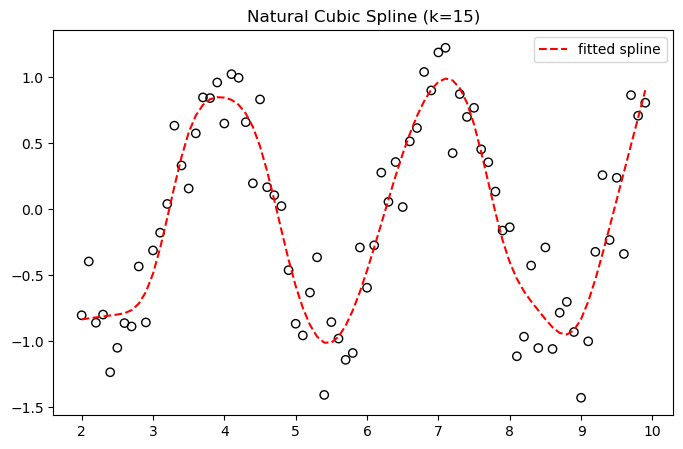

In [19]:
xpts = np.arange(2, 10, 0.1)
#xpts = np.random.uniform(0,10, 1000)
#xpts = np.sort(xpts)
f = np.sin(2*xpts)
ypts = f + np.random.normal(0, 0.3, len(xpts))

data = np.zeros((len(xpts), 2))
data[:, 0] = xpts
data[:, 1] = ypts

results = bmat(data, 15)

#### Case 3 

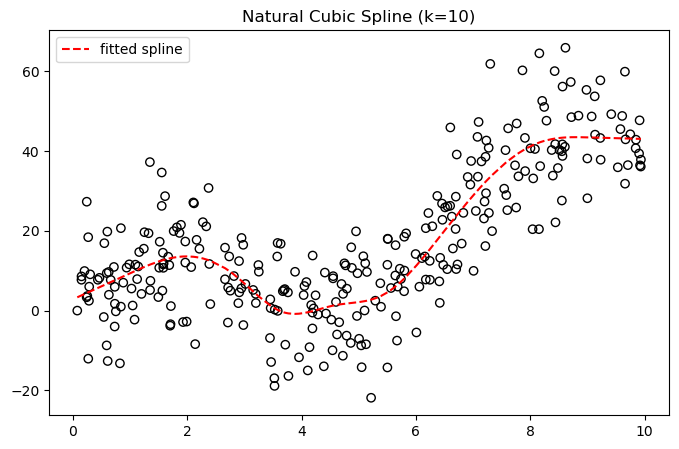

In [20]:
xpts = np.random.uniform(0, 10, 300)
xpts = np.sort(xpts)

f = 10*np.sin(xpts) + 0.5*xpts**2
ypts = f + np.random.normal(0, 10, len(xpts))

data = np.zeros((len(xpts), 2))
data[:, 0] = xpts
data[:, 1] = ypts

results = bmat(data, 10)